<a href="https://colab.research.google.com/github/gmustika1312-svg/test_project/blob/main/Assignment_Day_20_Advanced_Exploratory_Data_Analysis_GGMU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



1.   Berikut untuk poin-point assignment, harap dibaca dengan saksama sesuai keterangan yang ada pada soal Exploratory Data Analysis.
Link dataset : ecommerce.csv	    
2.   Anda bekerja sebagai seorang data scientist, atasan anda mengirimkan anda data kepada anda dan meminta untuk memberikan analisa dengan menggunakan :
- Semua metode pada proses Exploratory Data Analysis. Lakukan proses Feature Engineering terlebih dahulu dan mengecek secara teliti pada tiap kolom data sembari melakukan data understanding.
- Buat 5 pertanyaan analisa
- Jawab dengan pendekatan metode data manipulation (sorting, filtering, group by, pivot, melt, crosstab, working with datetime, dsb sesuaikan dengan keperluan anda terkait dengan pertanyaan analisa yang anda siapkan)
- Buatlah visualisasi grafik supaya mempermudah dalam ekstraksi insight setelah menjawab menggunakan metode data manipulation diatas
- Tulis insight anda dari hasil visualisasi yang anda lakukan sebagai bentuk jawaban dari pertanyaan analisis yang anda ajukan



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = "https://drive.google.com/uc?export=download&id=1QCJfqvNRfG2KsAgCG0pqdixvozvrsD9R"
data_ecommerce = pd.read_csv(url)

# Melihat 5 data teratas
data_ecommerce.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,554697,21166,COOK WITH WINE METAL SIGN,1,5/25/2011 17:31,2.08,14584,United Kingdom
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,7/24/2011 11:58,2.55,17114,United Kingdom
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,7/19/2011 12:54,1.65,15311,United Kingdom
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,7/13/2011 11:34,1.25,16843,United Kingdom
4,544450,21789,KIDS RAIN MAC PINK,3,2/20/2011 12:23,0.85,17811,United Kingdom


In [ ]:
# Melihat sample data
data_ecommerce.sample(5, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1654,542113,22891,TEA FOR ONE POLKADOT,3,1/25/2011 13:55,4.25,14341,United Kingdom
1101,575610,20717,STRAWBERRY SHOPPER BAG,10,11/10/2011 12:45,1.25,16628,United Kingdom
1149,572662,23295,SET OF 12 MINI LOAF BAKING CASES,8,10/25/2011 12:54,0.83,15443,United Kingdom
2763,552714,84946,ANTIQUE SILVER T-LIGHT GLASS,12,5/11/2011 9:28,1.25,17164,United Kingdom
3145,577807,23405,HOME SWEET HOME 2 DRAWER CABINET,4,11/22/2011 8:26,4.95,15699,United Kingdom


In [ ]:
data_ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4870 non-null   int64  
 1   StockCode    4870 non-null   object 
 2   Description  4870 non-null   object 
 3   Quantity     4870 non-null   int64  
 4   InvoiceDate  4870 non-null   object 
 5   UnitPrice    4870 non-null   float64
 6   CustomerID   4870 non-null   int64  
 7   Country      4870 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 304.5+ KB


In [ ]:
data_ecommerce.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID
count,4870.000000,4870.000000,4870.000000,4870.000000
mean,560586.577413,12.945791,2.937057,15291.004312
std,13211.347819,38.145988,4.744515,1709.035002
min,536365.000000,1.000000,0.040000,12347.000000
25%,548861.000000,2.000000,1.250000,13975.000000
50%,561895.000000,5.000000,1.950000,15144.000000
75%,572126.000000,12.000000,3.750000,16793.250000
max,581585.000000,992.000000,145.000000,18283.000000


In [ ]:
print("Shape               :", data_ecommerce.shape)
print("Jumlah Baris        :", data_ecommerce.shape[0])
print("Jumlah Kolom        :", data_ecommerce.shape[1])
print("Jumlah Missing Value:")
print(data_ecommerce.isnull().sum())
print("Jumlah Duplicated   :", data_ecommerce.duplicated().sum())

Shape               : (4870, 8)
Jumlah Baris        : 4870
Jumlah Kolom        : 8
Jumlah Missing Value:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
Jumlah Duplicated   : 0


Analisa:
*   Berdasarkan hasil pemeriksaan data, tidak ditemukan missing value maupun duplicate data pada dataset e-commerce. Oleh karena itu, tidak diperlukan proses Cleansing data (dropna maupun drop_duplicates), dan data dapat langsung digunakan untuk tahap feature engineering.



# **Feature Engineering**

In [ ]:
# Membuat salinan dataset
df = data_ecommerce.copy()

# Ekstraksi komponen Datetime dari InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayName'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

# Membuat kolom Total Sales (Revenue)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,DayName,Hour,TotalPrice
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom,2011,5,Wednesday,17,2.08
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom,2011,7,Sunday,11,5.10
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom,2011,7,Tuesday,12,1.65
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom,2011,7,Wednesday,11,15.00
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom,2011,2,Sunday,12,2.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4865,571883,23263,SET OF 3 WOODEN HEART DECORATIONS,1,2011-10-19 13:58:00,1.25,14704,United Kingdom,2011,10,Wednesday,13,1.25
4866,545530,21922,UNION STRIPE WITH FRINGE HAMMOCK,12,2011-03-03 13:45:00,6.95,17416,United Kingdom,2011,3,Thursday,13,83.40
4867,540458,21125,SET 6 FOOTBALL CELEBRATION CANDLES,12,2011-01-07 12:28:00,1.25,12501,Germany,2011,1,Friday,12,15.00
4868,574289,22999,TRAVEL CARD WALLET VINTAGE LEAF,24,2011-11-03 15:16:00,0.42,17750,United Kingdom,2011,11,Thursday,15,10.08


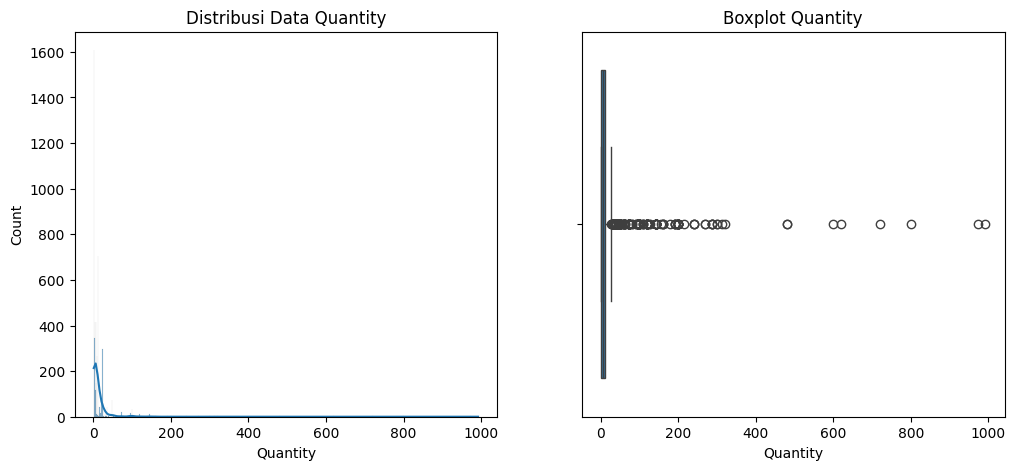

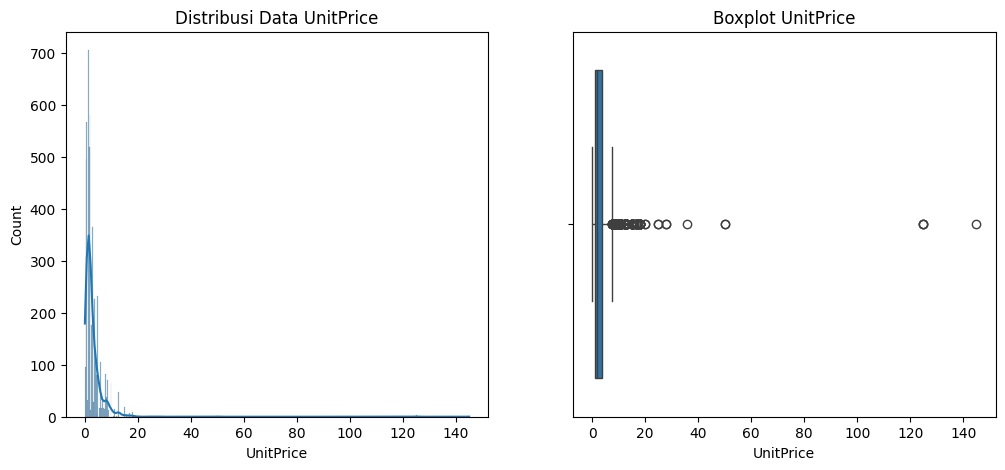

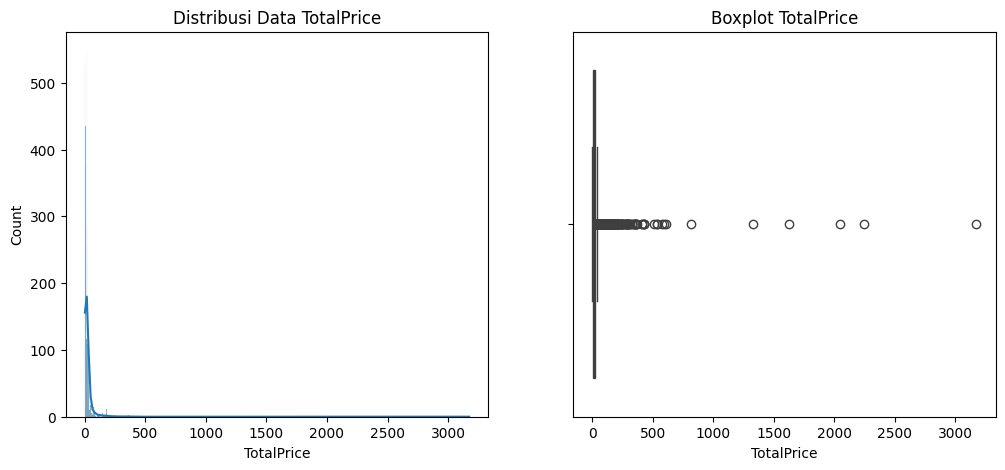

In [ ]:
# Mengecek distribusi
kolom_ecommerce = ['Quantity', 'UnitPrice', 'TotalPrice']
for kolom in kolom_ecommerce:
    plt.figure(figsize=(12,5))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(df[kolom], kde=True)
    plt.title(f'Distribusi Data {kolom}')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[kolom])
    plt.title(f'Boxplot {kolom}')

    plt.show()

In [ ]:
kolom_ecommerce = ['Quantity', 'UnitPrice', 'TotalPrice']
for kolom in kolom_ecommerce:
  Q1 = df[kolom].quantile(0.25)
  Q3 = df[kolom].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outlier_df = df[
      (df[kolom] < lower_bound) |
      (df[kolom] > upper_bound)
  ]
  print(f"{kolom}")
  print(f"Jumlah Outlier : {len(outlier_df)}")

Quantity
Jumlah Outlier : 328
UnitPrice
Jumlah Outlier : 406
TotalPrice
Jumlah Outlier : 403


Analisa:
*   Berdasarkan hasil perhitungan dengan menggunakan metode IQR, ditemukan outlier pada variabel Quantity sebanyak 328 data, UnitPrice sebanyak 406 data, dan Total Price sebanyak 403 data. Outlier tidak dihapus Karena masih merepresentasikan transaksi yang valid dalam konteks bisnis e-commerce. Selanjutnya, data transaksi dikelompokkan ke dalam beberapa segmen berdasarkan nilai TotalPrice untuk mempermudah analisis pola transaksi.

In [ ]:
# Segmentasi Transaksi
df['SegmentTransaction'] = pd.cut(
    df['TotalPrice'],
    bins=[
    df['TotalPrice'].min(),
    Q1,
    Q3,
    upper_bound,
    df['TotalPrice'].max()
    ],
    labels=['Low', 'Medium', 'High', 'Premium'],
    include_lowest=True
)

In [ ]:
df.sample(5, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,DayName,Hour,TotalPrice,SegmentTransaction
1654,542113,22891,TEA FOR ONE POLKADOT,3,2011-01-25 13:55:00,4.25,14341,United Kingdom,2011,1,Tuesday,13,12.75,Medium
1101,575610,20717,STRAWBERRY SHOPPER BAG,10,2011-11-10 12:45:00,1.25,16628,United Kingdom,2011,11,Thursday,12,12.50,Medium
1149,572662,23295,SET OF 12 MINI LOAF BAKING CASES,8,2011-10-25 12:54:00,0.83,15443,United Kingdom,2011,10,Tuesday,12,6.64,Medium
2763,552714,84946,ANTIQUE SILVER T-LIGHT GLASS,12,2011-05-11 09:28:00,1.25,17164,United Kingdom,2011,5,Wednesday,9,15.00,Medium
3145,577807,23405,HOME SWEET HOME 2 DRAWER CABINET,4,2011-11-22 08:26:00,4.95,15699,United Kingdom,2011,11,Tuesday,8,19.80,High


Analisa:
*   Segmentasi transaksi dilakukan dengan mengelompokkan nilai transaksi (**TotalPrice**) ke dalam kategori "Low", "Medium", "High", dan "Premium" berdasarkan batas kuartil dan metode IQR. Pengelompokan ini bertujuan untuk mempermudah identifikasi karakteristik transaksi pada setiap tingkat nilai penjualan dalam analisis selanjutnya.




# Question 1:
Segmen transaksi mana yang memberikan kontibusi terbesar terhadap revenue (TotalPrice)?

In [ ]:
# Total revenue per segment
segment_revenue = (
    df.groupby('SegmentTransaction')['TotalPrice']
      .sum()
      .reset_index()
      .sort_values(by='TotalPrice', ascending=False)
)

# Menghitung persentase kontribusi
segment_revenue['Contribution (%)'] = (
    segment_revenue['TotalPrice'] /
    segment_revenue['TotalPrice'].sum() * 100
)

segment_revenue

/tmp/ipykernel_5087/393787371.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('SegmentTransaction')['TotalPrice']


,SegmentTransaction,TotalPrice,Contribution (%)
3,Premium,59009.21,52.790533
1,Medium,29413.67,26.313915
2,High,20498.03,18.337848
0,Low,2859.00,2.557705


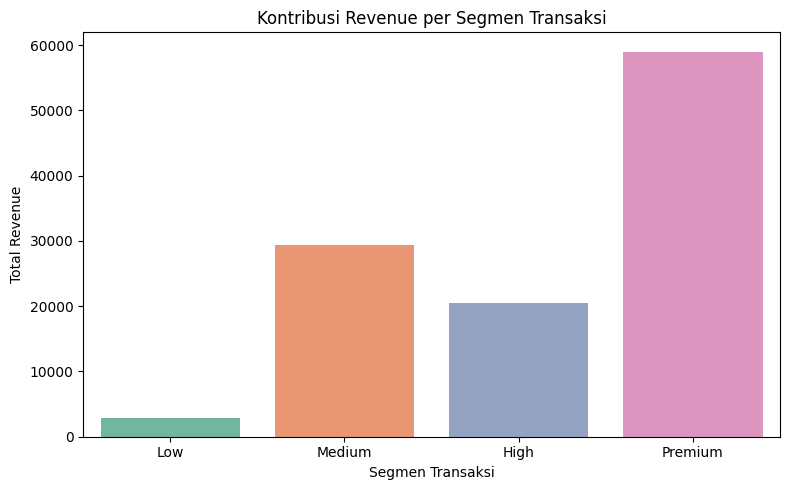

In [ ]:
# Visualisasi
plt.figure(figsize=(8,5))

# Bar Chart
ax = sns.barplot(
    data=segment_revenue,
    x='SegmentTransaction',
    y='TotalPrice',
    hue='SegmentTransaction',
    palette='Set2',
    legend=False
)

plt.title('Kontribusi Revenue per Segmen Transaksi')
plt.xlabel('Segmen Transaksi')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

# Q1.

**Analisa**
*   Berdasarkan hasil pengolahan data dan visualisasi, segmen "Premium" memberikan kontribusi revenue terbesar berdasarkan (TotalPrice) dengan nilai 59.009,21 atau 52,79% dari total keseluruhan revenue perusahaan. Kontribusi tersebut lebih tinggi dibandingkan dengan segmen  lain, seperti "Medium" (26,31%), "High" (18,34%), dan "Low" (2,56%), sehingga pendapatan perusahaan didominasi oleh segmen Premium.

**Insight**
*   Dengan tingginya kontribusi segmen Premium terhadap revenue perusahaan, pelanggan pada segmen ini perlu dipertahankan melalui program loyalitas dan penawaran khusus. Sementara itu, pelanggan pada segmen High dapat didorong untuk naik ke segmen Premium melalui strategi yang meningkatkan nilai transaksi. Di sisi lain, segmen Medium dan Low masih memiliki potensi untuk Dikembangkan melalui program promosi yang mendorong peningkatan frekuensi dan nilai pembelian. Dengan demikian, perusahaan tidak hanya mempertahankan sumber revenue utama, tetapi juga meningkatkan kontribusi revenue dari segmen lainnya secara berkelanjutan.

#**Question 2** :
Produk apa yang paling berkontribusi terhadap revenue pada segmen tersebut?

In [ ]:
# Filter segmen Premium
premium_df = df[df['SegmentTransaction'] == 'Premium']

# Revenue per product pada segmen Premium
product_revenue = (
    premium_df.groupby('Description')['TotalPrice']
              .sum()
              .reset_index()
              .sort_values(by='TotalPrice', ascending=False)
)

# Hitung kontribusi (%)
product_revenue['Contribution (%)'] = (
    product_revenue['TotalPrice'] /
    product_revenue['TotalPrice'].sum() * 100
)

product_revenue.head(10)

,Description,TotalPrice,Contribution (%)
281,WHITE HANGING HEART T-LIGHT HOLDER,3787.90,6.419167
52,CREAM HEART CARD HOLDER,2414.76,4.092175
260,SWEETHEART BIRD HOUSE,2046.00,3.467255
19,BLACK RECORD COVER FRAME,1789.92,3.033289
108,HOT WATER BOTTLE I AM SO POORLY,1326.00,2.247107
123,JUMBO BAG RED RETROSPOT,1146.70,1.943256
205,REGENCY CAKESTAND 3 TIER,1057.95,1.792856
168,PAPER CHAIN KIT EMPIRE,962.25,1.630678
126,JUMBO BAG STRAWBERRY,925.50,1.568399
116,JUMBO BAG ALPHABET,895.00,1.516712


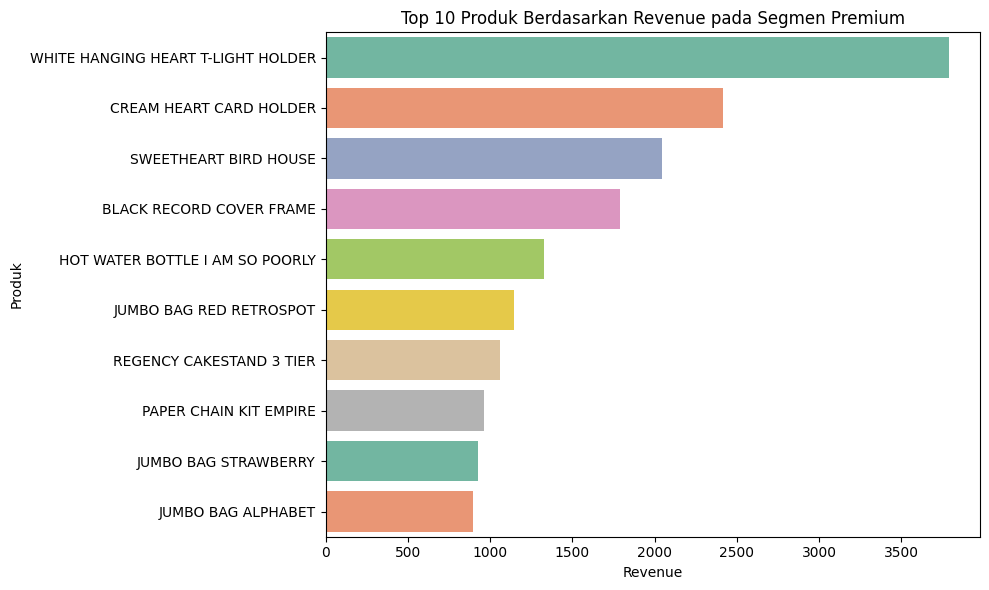

In [ ]:
# Visualisasi
top10_product = product_revenue.head(10)
plt.figure(figsize=(10,6))

# Bar Chart
sns.barplot(
    data=top10_product,
    x='TotalPrice',
    y='Description',
    hue='Description',
    palette='Set2',
    legend=False
)

plt.title('Top 10 Produk Berdasarkan Revenue pada Segmen Premium')
plt.xlabel('Revenue')
plt.ylabel('Produk')

plt.tight_layout()
plt.show()

# Q2.

**Analisa**
*   Berdasarkan hasil analisis pada segmen transaksi Premium, produk WHITE HANGING HEART T-LIGHT HOLDER merupakan produk dengan kontribusi revenue terbesar, yaitu sebesar 3.787,90 atau 6,42% dari total revenue segmen tersebut. Produk ini menempati posisi teratas, diikuti oleh CREAM HEART CARD HOLDER dengan kontribusi 4,09% dan SWEETHEART BIRD HOUSE sebesar 3,47%. Hasil tersebut menunjukkan bahwa produk-produk bertema dekorasi rumah mendominasi kontribusi revenue pada pelanggan segmen Premium.

**Insight**
*   Produk dengan kontribusi revenue tinggi, seperti WHITE HANGING HEART T-LIGHT HOLDER, CREAM HEART CARD HOLDER, dan SWEETHEART BIRD HOUSE, menjadi kontributor utama revenue pada segmen Premium. Oleh karena itu, perusahaan perlu memastikan ketersediaannya serta memanfaatkan strategi product bundling dengan menggabungkan produk-produk terkait dalam satu paket penjualan. Strategi ini berpotensi meningkatkan nilai transaksi pelanggan sekaligus mendorong penjualan item lain yang kontribusi revenue yang masih relatif rendah.

# Question 3:
Revenue yang tinggi pada segmen premium lebih dipengaruhi oleh banyaknya transaksi atau tingginya nilai transaksi?

In [ ]:
# Agregasi nilai transaksi per invoice
invoice_summary = (
    df.groupby('InvoiceNo')
      .agg(
          SegmentTransaction=('SegmentTransaction', 'first'),
          TransactionValue=('TotalPrice', 'sum')
      )
      .reset_index()
)

invoice_summary.head()

,InvoiceNo,SegmentTransaction,TransactionValue
0,536365,High,22.00
1,536381,Low,1.95
2,536394,Premium,177.60
3,536397,Premium,55.80
4,536404,Medium,13.20


In [ ]:
# Mengelompokkan data berdasarkan segmen transaksi
segment_summary = (
    invoice_summary.groupby('SegmentTransaction')
    .agg(
        Total_Transaction=('InvoiceNo', 'count'),
        Median_Transaction_Value=('TransactionValue', 'median'),
        Average_Transaction_Value=('TransactionValue', 'mean'),
        Total_Revenue=('TransactionValue', 'sum')
    )
    .reset_index()
    .sort_values(by='Total_Revenue', ascending=False)
)

segment_summary

/tmp/ipykernel_5087/3350775448.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  invoice_summary.groupby('SegmentTransaction')


,SegmentTransaction,Total_Transaction,Median_Transaction_Value,Average_Transaction_Value,Total_Revenue
3,Premium,343,88.80,167.155773,57334.43
1,Medium,1970,14.50,15.350076,30239.65
2,High,646,28.26,30.964985,20003.38
0,Low,845,2.95,4.973314,4202.45


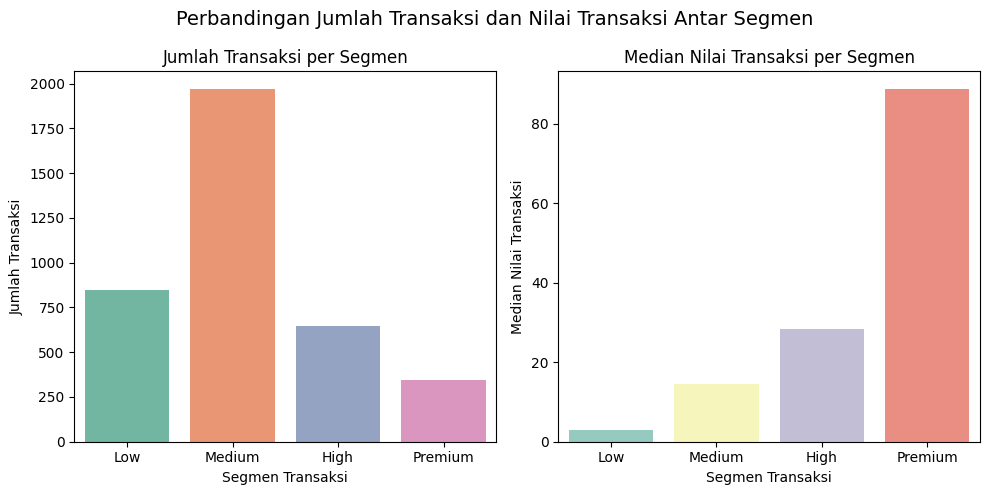

In [ ]:
# Visualisasi
fig, ax = plt.subplots(1, 2, figsize=(10,5))

# Plot 1: Jumlah transaksi
sns.barplot(
    data=segment_summary,
    x='SegmentTransaction',
    y='Total_Transaction',
    hue='SegmentTransaction',
    palette='Set2',
    legend=False,
    ax=ax[0]
)

ax[0].set_title('Jumlah Transaksi per Segmen')
ax[0].set_xlabel('Segmen Transaksi')
ax[0].set_ylabel('Jumlah Transaksi')

# Plot 2: Median nilai transaksi
sns.barplot(
    data=segment_summary,
    x='SegmentTransaction',
    y='Median_Transaction_Value',
    hue='SegmentTransaction',
    palette='Set3',
    legend=False,
    ax=ax[1]
)

ax[1].set_title('Median Nilai Transaksi per Segmen')
ax[1].set_xlabel('Segmen Transaksi')
ax[1].set_ylabel('Median Nilai Transaksi')

plt.suptitle(
    'Perbandingan Jumlah Transaksi dan Nilai Transaksi Antar Segmen',
    fontsize=14
)

plt.tight_layout()
plt.show()

# Q3.

**Analisa**
*   Berdasarkan hasil agregasi dan pengelompokan data, segmen Medium memiliki jumlah transaksi tertinggi sebanyak 1.970 transaksi, diikuti oleh segmen Low (845 transaksi), High (646 transaksi), dan Premium (343 transaksi). Namun, meskipun memiliki jumlah transaksi paling sedikit, segmen Premium mencatat median nilai transaksi tertinggi sebesar 88,80, jauh lebih tinggi dibandingkan segmen High (28,26), Medium (14,50), dan Low (2,95). Temuan ini menunjukkan bahwa Tingginya revenue pada segmen Premium lebih dipengaruhi oleh besarnya nilai transaksi per pembelian dibandingkan dengan banyaknya transaksi yang terjadi.

**Insight**
*   Hasil analisis menunjukkan bahwa tingginya jumlah transaksi tidak selalu menghasilkan revenue yang lebih besar. Segmen Medium mencatat frekuensi transaksi tertinggi, namun segmen Premium tetap menghasilkan revenue terbesar karena memiliki nilai transaksi yang jauh lebih tinggi. Kondisi ini menunjukkan bahwa peningkatan nilai transaksi memberikan dampak yang lebih signifikan terhadap revenue dibandingkan peningkatan jumlah transaksi. Berdasarkan hasil tersebut, perusahaan perlu memprioritaskan strategi yang mampu meningkatkan nilai pembelian pelanggan dalam setiap transaksi guna mendorong pertumbuhan revenue yang lebih optimal. dengan

# Question 4:
Negara mana yang memberikan kontribusi revenue terbesar pada segmen Premium?

In [ ]:
# Filter segmen Premium
premium_df = df[df['SegmentTransaction'] == 'Premium']

# Revenue per country
country_revenue = (
    premium_df.groupby('Country')['TotalPrice']
    .sum()
    .reset_index()
    .sort_values(by='TotalPrice', ascending=False)
)

# Persentase kontribusi
country_revenue['Contribution (%)'] = (
    country_revenue['TotalPrice'] /
    country_revenue['TotalPrice'].sum() * 100
).round(2)

country_revenue.head(10)

,Country,TotalPrice,Contribution (%)
15,United Kingdom,47888.16,81.15
10,Netherlands,3565.38,6.04
3,EIRE,1747.26,2.96
6,Germany,1446.37,2.45
5,France,1090.30,1.85
13,Sweden,848.40,1.44
0,Australia,756.60,1.28
14,Switzerland,443.36,0.75
4,Finland,346.08,0.59
11,Portugal,302.40,0.51


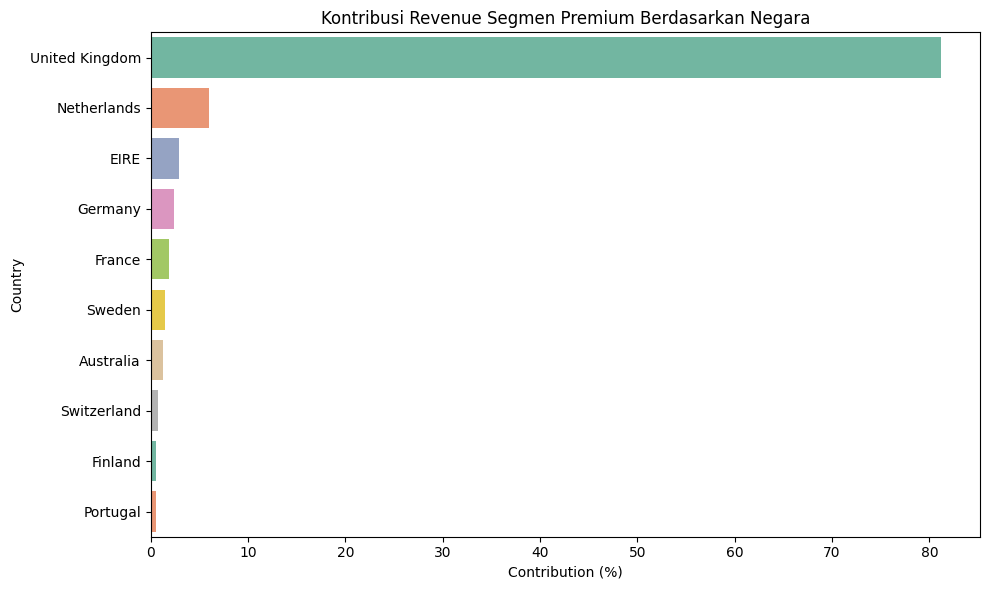

In [ ]:
# Visualisasi
top10_country = country_revenue.head(10)
plt.figure(figsize=(10,6))

# Bar Chart
sns.barplot(
    data=top10_country,
    x='Contribution (%)',
    y='Country',
    hue='Country',
    palette='Set2',
    legend=False
)

plt.title('Kontribusi Revenue Segmen Premium Berdasarkan Negara')
plt.xlabel('Contribution (%)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

# Q4.

**Analisa**
*   Berdasarkan hasil pengolahan data dan visualisasi, United Kingdom menjadi negara dengan kontribusi revenue terbesar pada segmen **"Premium"** sebesar 81,15%. Posisi berikutnya ditempati oleh **Netherlands (6,04%), EIRE (2,96%), Germany (2,45%), France (1,85%), Sweden (1,44%), Australia (1,28%), Switzerland (0,75%), Finland (0,59%)**, dan **Portugal (0,51%)**. Perbedaan kontribusi yang sangat signifikan antara United Kingdom dan negara lainnya menunjukkan bahwa revenue pada segmen Premium didominasi oleh pelanggan dari satu negara tertentu.

**Insight**
*   Sebagian besar revenue segmen Premium berasal dari United Kingdom, sedangkan kontribusi negara lain masih relatif terbatas. Hal ini menunjukkan bahwa pasar utama pada segmen Premium berada di United Kingdom. Oleh karena itu, terdapat peluang untuk meningkatkan kontribusi revenue dari negara lain seperti Netherlands, EIRE, dan Germany melalui pengembangan pasar dan peningkatan keterlibatan pelanggan pada negara-negara tersebut.

# Question 5:
Bagaimana tren revenue pada segmen Premium sepanjang tahun 2011?

In [ ]:
# Filter segmen Premium dan tahun 2011
premium_2011 = df[
    (df['SegmentTransaction'] == 'Premium') &
    (df['Year'] == 2011)
]

# Revenue bulanan tahun 2011
monthly_revenue = (
    premium_2011.groupby('Month')['TotalPrice']
    .sum()
    .reset_index()
    .sort_values('Month')
)

monthly_revenue

,Month,TotalPrice
0,1,3329.83
1,2,3107.18
2,3,3543.73
3,4,3055.70
4,5,2666.56
5,6,3952.58
6,7,3966.98
7,8,5854.60
8,9,4287.59
9,10,4070.03


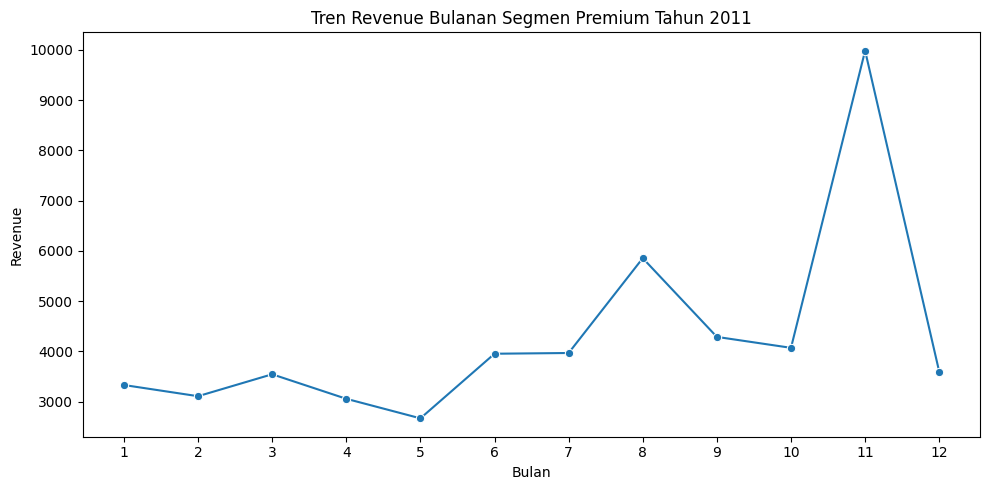

In [ ]:
# Visualisasi
plt.figure(figsize=(10,5))

# Line Chart
sns.lineplot(
    data=monthly_revenue,
    x='Month',
    y='TotalPrice',
    marker='o'
)

plt.title('Tren Revenue Bulanan Segmen Premium Tahun 2011')
plt.xlabel('Bulan')
plt.ylabel('Revenue')

plt.xticks(range(1,13))

plt.tight_layout()
plt.show()

# Q5.

**Analisa**
*   Berdasarkan hasil pengolahan data dan visualisasi, revenue segmen **"Premium"** selama tahun 2011 menunjukkan pola yang fluktuatif. Revenue terendah terjadi pada **Mei** sebesar **2.666,56**, kemudian mengalami **peningkatan secara bertahap** mulai bulan **Juni** hingga mencapai **5.854,60** pada **Agustus**. Setelah mengalami **penurunan** pada bulan **September** dan **Oktober**, revenue **kembali meningkat secara signifikan** dan mencapai puncaknya pada November sebesar **9.983,69**, sebelum **kembali turun** menjadi **3.593,83** pada **Desember**.

**Insight**
*   Peningkatan revenue yang cukup tajam pada periode Agustus hingga November menunjukkan adanya periode dengan aktivitas pembelian yang lebih tinggi dibandingkan dengan bulan lainnya. Kondisi ini dapat dimanfaatkan sebagai acuan dalam perencanaan promosi, pengelolaan persediaan, dan penyusunan strategi penjualan agar perusahaan dapat mengoptimalkan potensi revenue pada periode dengan permintaan yang tinggi.

# KESIMPULAN

Hasil analisis menunjukkan bahwa segmen Premium merupakan kontributor utama pendapatan dengan kontribusi sebesar 52,79% terhadap total revenue. Tingginya kontribusi segmen ini tidak didorong oleh jumlah transaksi, melainkan oleh nilai transaksi yang lebih tinggi dibandingkan segmen lainnya. Pada segmen Premium, produk WHITE HANGING HEART T-LIGHT HOLDER, CREAM HEART CARD HOLDER, dan SWEETHEART BIRD HOUSE menjadi produk dengan kontribusi revenue terbesar. Selain itu, revenue segmen Premium sangat terkonsentrasi di United Kingdom yang menyumbang 81,15% dari total revenue segmen tersebut. Sepanjang tahun 2011, revenue segmen Premium menunjukkan pola yang fluktuatif, dengan peningkatan yang cukup signifikan pada periode Agustus hingga November dan mencapai puncaknya pada bulan November. Hasil tersebut menunjukkan bahwa pembentukan revenue pada segmen Premium dipengaruhi oleh tingginya nilai transaksi, kontribusi beberapa produk utama, serta konsentrasi pelanggan pada pasar tertentu.